In [1]:
# ============================================================
# CELL 1: Imports
# ============================================================
import os
import shutil
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Gerät: {device}")

model_id  = "openai/clip-vit-large-patch14"
processor = CLIPProcessor.from_pretrained(model_id)
model     = CLIPModel.from_pretrained(model_id).to(device)
model.eval()
print(f"Modell geladen: {model_id}")

C:\Users\Lukas\miniconda3\envs\kilimanjaro\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gerät: cuda


Loading weights: 100%|█████████████████████████████████████████████████████████████| 590/590 [00:00<00:00, 3636.19it/s]


Modell geladen: openai/clip-vit-large-patch14


In [2]:
# ============================================================
# CELL 2: Prompts
# ============================================================
categories = ["indoor", "outdoor"]

category_texts = [
    "a photo taken inside a room showing walls, ceiling, furniture, artificial lighting or floor",
    "a photo taken outdoors showing open spaces such as nature, sky, streets, buildings, parks or landscapes"
]

text_inputs = processor(text=category_texts, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    text_out      = model.get_text_features(**text_inputs)
    text_features = text_out if isinstance(text_out, torch.Tensor) else text_out.pooler_output
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Kategorien:", categories)
print("Text-Embeddings berechnet:", text_features.shape)

Kategorien: ['indoor', 'outdoor']
Text-Embeddings berechnet: torch.Size([2, 768])


In [3]:
# ============================================================
# CELL 3: Pfade – Evaluierungsbilder
# ============================================================
image_folder = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_sorted"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = []

for subfolder in ['indoor', 'outdoor']:
    folder = os.path.join(image_folder, subfolder)
    if not os.path.exists(folder):
        print(f'⚠ Ordner nicht gefunden: {folder}')
        continue
    for fname in sorted(os.listdir(folder)):
        if fname.startswith("augmented_"):
            continue
        ext = os.path.splitext(fname)[1].lower()
        if ext not in VALID_EXTENSIONS:
            continue
        fpath = os.path.join(folder, fname)
        if os.path.isfile(fpath):
            image_paths.append(fpath)

print(f"Bilder gefunden: {len(image_paths)}")

Bilder gefunden: 700


In [4]:
# ============================================================
# CELL 4: Klassifikation
# ============================================================
def safe_open(path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError) as e:
        print(f"  ⚠ Skipped ({os.path.basename(path)}): {e}")
        return None

BATCH_SIZE = 32

results     = []
confidences = []
valid_paths = []

for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Batches"):
    batch_paths = image_paths[i : i + BATCH_SIZE]
    loaded      = [(p, safe_open(p)) for p in batch_paths]
    loaded      = [(p, img) for p, img in loaded if img is not None]

    if not loaded:
        continue

    paths_ok, imgs_ok = zip(*loaded)

    img_inputs = processor(
        images=list(imgs_ok),
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        image_out      = model.get_image_features(**img_inputs)
        image_features = image_out if isinstance(image_out, torch.Tensor) else image_out.pooler_output
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarities = image_features @ text_features.T
    batch_preds  = similarities.argmax(dim=1).cpu().numpy()
    batch_conf   = similarities.max(dim=1).values.cpu().float().numpy()

    results.extend([categories[idx] for idx in batch_preds])
    confidences.extend(batch_conf)
    valid_paths.extend(paths_ok)

print(f"\nKlassifiziert: {len(results)} Bilder")
print("\nVorhersage-Verteilung:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)}")

Batches: 100%|██████████████████████████████████████████████████████████████████████| 22/22 [1:01:07<00:00, 166.71s/it]


Klassifiziert: 700 Bilder

Vorhersage-Verteilung:
  indoor: 290
  outdoor: 410


In [5]:
# ============================================================
# CELL 5: Bilder sortieren
# ============================================================
output_base = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_eval_sorted"

sorted_dirs = {cat: os.path.join(output_base, cat) for cat in categories}
for d in sorted_dirs.values():
    os.makedirs(d, exist_ok=True)

for path, pred in zip(valid_paths, results):
    shutil.copy(path, sorted_dirs[pred])

print("Bilder sortiert:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)} → {sorted_dirs[cat]}")

Bilder sortiert:
  indoor: 290 → C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_eval_sorted\indoor
  outdoor: 410 → C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_eval_sorted\outdoor


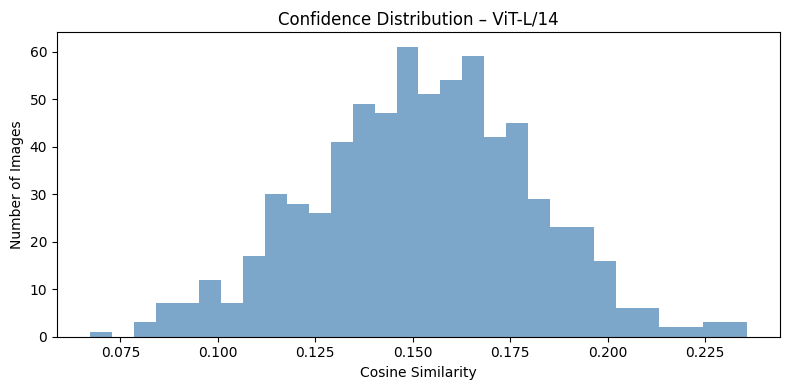

In [6]:
# ============================================================
# CELL 6: Konfidenz visualisieren
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(confidences, bins=30, alpha=0.7, color="steelblue")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence Distribution – ViT-L/14")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7: CSV speichern
# ============================================================
output_csv = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_eval_sorted\vitl14_labels.csv"

df_results = pd.DataFrame({
    "file_name":  [os.path.basename(p) for p in valid_paths],
    "pred_label": results,
    "confidence": confidences
})

df_results.to_csv(output_csv, index=False)
print(f"Labels gespeichert: {output_csv}")
print()
print("Verteilung:")
print(df_results["pred_label"].value_counts())
print(f"\nGesamt: {len(df_results)} Bilder")

Labels gespeichert: C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_eval_sorted\vitl14_labels.csv

Verteilung:
pred_label
outdoor    410
indoor     290
Name: count, dtype: int64

Gesamt: 700 Bilder


In [8]:
# ============================================================
# CELL 8: Unsicherste Bilder
# ============================================================
df_uncertain = df_results.nsmallest(10, "confidence")
print(df_uncertain)

          file_name pred_label  confidence
531   image_961.jpg    outdoor    0.067126
248  image_6564.jpg     indoor    0.078510
105  image_3039.jpg     indoor    0.082740
109  image_3330.jpg     indoor    0.083964
169  image_4658.jpg     indoor    0.084852
264   image_718.jpg     indoor    0.084852
61   image_2498.jpg    outdoor    0.087568
516   image_958.jpg    outdoor    0.088065
483   image_955.jpg    outdoor    0.088281
537   image_967.jpg    outdoor    0.088549


Evaluierbare Bilder: 700

Accuracy:              0.9143
Ø Confidence (Cosine): 0.1525

              precision    recall  f1-score   support

      indoor       1.00      0.83      0.91       350
     outdoor       0.85      1.00      0.92       350

    accuracy                           0.91       700
   macro avg       0.93      0.91      0.91       700
weighted avg       0.93      0.91      0.91       700



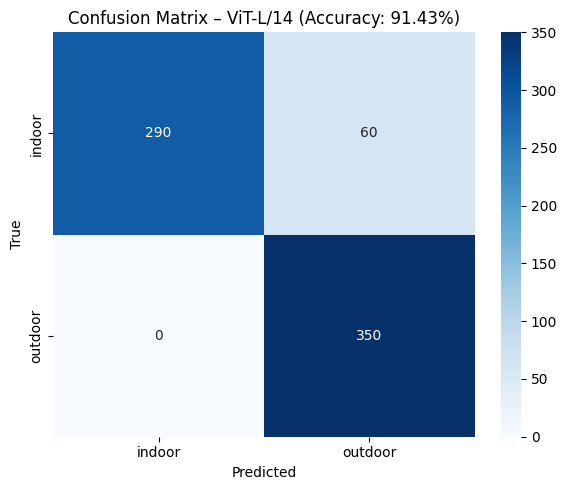

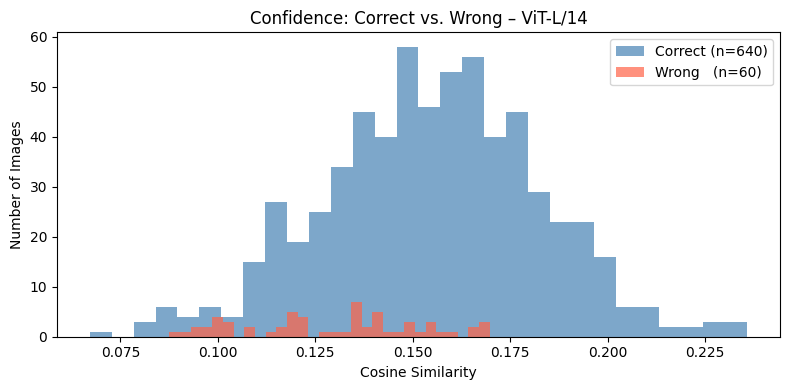


Unsicherste 10 Bilder:
          file_name true_label pred_label  confidence
531   image_961.jpg    outdoor    outdoor    0.067126
248  image_6564.jpg     indoor     indoor    0.078510
105  image_3039.jpg     indoor     indoor    0.082740
109  image_3330.jpg     indoor     indoor    0.083964
169  image_4658.jpg     indoor     indoor    0.084852
264   image_718.jpg     indoor     indoor    0.084852
61   image_2498.jpg     indoor    outdoor    0.087568
516   image_958.jpg    outdoor    outdoor    0.088065
483   image_955.jpg    outdoor    outdoor    0.088281
537   image_967.jpg    outdoor    outdoor    0.088549

── Alle Dateien gespeichert in: C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_eval_sorted\evaluation ──


In [9]:
# ============================================================
# CELL 9: Evaluation mit Ground Truth Labels
# ============================================================
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

output_dir = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_eval_sorted\evaluation"
os.makedirs(output_dir, exist_ok=True)

label_csv   = r"C:\Users\Lukas\Downloads\flickr-resnet50-aestheticNCP\data\flickr_images\vitl14_sorted\photo_labels_indoor_outdoor.csv"
df_labels   = pd.read_csv(label_csv)
labels_dict = dict(zip(df_labels["file_name"], df_labels["Main_focus"]))

df_results["true_label"] = df_results["file_name"].map(labels_dict)
df_eval = df_results.dropna(subset=["true_label"])
print(f"Evaluierbare Bilder: {len(df_eval)}")

true     = df_eval["true_label"].values
pred     = df_eval["pred_label"].values
accuracy = accuracy_score(true, pred)
avg_conf = float(np.mean(df_eval["confidence"]))

print(f"\nAccuracy:              {accuracy:.4f}")
print(f"Ø Confidence (Cosine): {avg_conf:.4f}")
print()
print(classification_report(true, pred, target_names=sorted(categories)))

pd.DataFrame(
    classification_report(true, pred,
                          target_names=sorted(categories),
                          output_dict=True)
).transpose().to_csv(os.path.join(output_dir, "vitl14_metrics.csv"))

le = LabelEncoder()
le.classes_ = np.array(sorted(categories))
cm = confusion_matrix(le.transform(true), le.transform(pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – ViT-L/14 (Accuracy: {accuracy:.2%})")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "vitl14_confusion_matrix.png"),
            dpi=150, bbox_inches='tight')
plt.show()

correct      = (df_eval["true_label"] == df_eval["pred_label"]).tolist()
conf_correct = [c for c, ok in zip(df_eval["confidence"], correct) if ok]
conf_wrong   = [c for c, ok in zip(df_eval["confidence"], correct) if not ok]

plt.figure(figsize=(8, 4))
plt.hist(conf_correct, bins=30, alpha=0.7,
         label=f"Correct (n={len(conf_correct)})", color="steelblue")
plt.hist(conf_wrong,   bins=30, alpha=0.7,
         label=f"Wrong   (n={len(conf_wrong)})",   color="tomato")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence: Correct vs. Wrong – ViT-L/14")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "vitl14_confidence_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()

df_uncertain = df_eval.nsmallest(10, "confidence")[
    ["file_name", "true_label", "pred_label", "confidence"]]
print("\nUnsicherste 10 Bilder:")
print(df_uncertain)
df_uncertain.to_csv(os.path.join(output_dir, "vitl14_most_uncertain.csv"), index=False)

print(f"\n── Alle Dateien gespeichert in: {output_dir} ──")